# Pei & Roithmayr Case 1: response to initial conditions

This replicates the results of Pei & Roithmayr, *Equations of Motion for a Generic Multibody Tilt-rotor Aircraft* (AIAA 2022-3511, [NASA PDF](https://ntrs.nasa.gov/api/citations/20220006374/downloads/tiltrotor_dynamics_v14.pdf)), Section III, 

Case 1 is a four-rotor tilt-rotor in vacuum, with no gravity, thrust or joint torques, released with initial body, tilt and spin rates. The front rotors are larger than rear ones (the exact configuration being explored).

If we runn it with `DrakeMultirotor` and plot the body speeds `u1..u6` (the paper shows them in Fig. 2). They map directly onto our state variables (table below), so matching Fig. 2 serves as verification of the implementation.

Running it and exploring the plots shows, at least compared "by eye", that the implementation is able to simulate accurately the physics of the tiltrotor in this scenario.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

from rotorpy.vehicles.drake.multirotor import DrakeMultirotor

T_END, DT = 20.0, 0.05
T = np.arange(0.0, T_END + DT / 2, DT)

## Paper generalized speeds vs. our state

The paper has `6 + 2n = 14` generalized speeds (it uses Kane's method to solve the dynamics of the system), all in FRD body components. `DrakeMultirotor` state is FLU (z-up world), and its translational state belongs to the **total** centre of mass rather than to the fuselage centre `B*`. `FRD_TO_FLU = diag(1, -1, -1)` does the axis flip. 

| paper | meaning (paper, FRD) | our state | conversion |
|---|---|---|---|
| `u1, u2, u3` | velocity of `B*` along `b1, b2, b3` | `v` (world-frame velocity of total COM), `w`, `tilt_angles`, `tilt_rates` | `FRD_TO_FLU @ (R.T @ v - w × r_com - m_r Σ k̇_i / m_tot)` |
| `u4` | roll rate, `ω·b1` | `w[0]` | `u4 = w[0]` |
| `u5` | pitch rate, `ω·b2` | `w[1]` | `u5 = -w[1]` |
| `u6` | yaw rate, `ω·b3` | `w[2]` | `u6 = -w[2]` |
| `u7..u10` | tilt rate `δ̇_i` about `b2` | `tilt_rates[i]` (about FLU `+y`) | `u(6+i) = -tilt_rates[i]` |
| `u11..u14` | rotor spin rate `φ̇_i` about the rotor axis `c1`, relative to the nacelle | `rotor_speeds[i]` (always ≥ 0), `rotor_directions` = σ_i | `u(10+i) = -σ_i · rotor_speeds[i]` |

The configuration variables follow the same pattern: tilt angle `δ_i = -tilt_angles[i]`, and attitude is `q` (SciPy `[x, y, z, w]`, body to world). `r_com` is the total COM measured from `B*` in body axes, `k_i` is the rotor-`i` centre and `k̇_i` its velocity relative to the airframe (see `rotor_centres`). Rotors `i = 1..4` are front L, front R, rear L, rear R, in that order.

## The aircraft and physics simulated

A quadplane-like layout: a fuselage with two front rotors on the wing tips and two rear rotors closer in, lower and further aft. Each rotor sits `l = 1 m` ahead of its tilt hinge, and each nacelle is massless. 

Below it is defined using our general model: FLU body frame, z-up world, tilt about `+y`, spin sign from `rotor_directions`. The paper uses FRD axes and the fuselage-centre (`B*`) velocity.

**No external forces or torques are simulated**, the aircraft evolves freely and its kinetic energy and angular momentum are conserved. 

That is still enough to simulate what a single-rigid-body model cannot. Rotor spin momentum whose direction changes as the rotors tilt, an inertia tensor and centre of mass that move with the tilt, and momentum exchanged between the fuselage and the free tilt and spin joints.

In [2]:
# Assembly and rotor parameters for the quadrotor in our simulation

FRD_TO_FLU = np.diag([1.0, -1.0, -1.0])     # flips y and z; its own inverse

M_BODY, M_ROTOR, L_ARM = 2176.0, 118.0, 1.0  # kg, kg, m
I_BODY = np.diag([74110.0, 6780.0, 74529.0])  # kg m^2 (same diagonal in FRD and FLU)
IS, IT = 137.0, 69.0                          # rotor polar / transverse inertia, kg m^2
PIVOTS_FRD = np.array([[0.5, -5.5, -0.25],    # front left
                       [0.5, 5.5, -0.25],     # front right
                       [-2.5, -2.5, -0.5],    # rear left
                       [-2.5, 2.5, -0.5]])    # rear right
PIVOTS = PIVOTS_FRD @ FRD_TO_FLU              # FLU hinge pivots, m
HINGE = np.array([0.0, 1.0, 0.0])             # tilt axis (+y FLU)
SPIN_DIRECTIONS = np.array([-1.0, 1.0, -1.0, 1.0])  # sigma; spin rate about +x is -sigma * speed
M_TOTAL = M_BODY + 4 * M_ROTOR

def make_params(rotor_inertia):
    return {
        'airframe': {'mass': M_BODY, 'com_offset': np.zeros(3), 'inertia': I_BODY},
        'assemblies': [{'mass': 0.0, 'pivot': p, 'com_offset': np.zeros(3), 'inertia': np.zeros((3, 3)),
                        'hinge_axis': HINGE, 'wn': 1.0, 'zeta': 1.0, 'rate_limit': 1e3, 'accel_limit': 1e3}
                       for p in PIVOTS],
        'rotors': [{'assembly': i, 'hub_offset': [L_ARM, 0.0, 0.0], 'thrust_axis': [1.0, 0.0, 0.0],
                    'mass': M_ROTOR, 'inertia': rotor_inertia} for i in range(4)],
        'rotor_directions': SPIN_DIRECTIONS,
        # No aerodynamics: thrust and drag coefficients are effectively zero.
        'k_eta': 1e-30, 'k_m': 1e-30, 'k_d': 0.0, 'k_z': 0.0, 'k_h': 0.0, 'k_flap': 0.0,
        'tau_m': 0.05, 'rotor_speed_min': 0.0, 'rotor_speed_max': 1e4,
    }

# This implementation takes rotor inertia in the rotor frame (z = spin axis).
DRAKE_PARAMS = make_params(np.diag([IT, IT, IS]))

## Initial state

Paper values (Case 1, p. 8): `u1 = 100 m/s`, `u2 = u3 = 0`, body rates `(u4, u5, u6) = (-2.865, 5.73, 1.146) deg/s`, all tilt rates `5.73 deg/s`, zero tilt, spin `5443.5 deg/s`. 

In [3]:
U_PAPER = np.concatenate([[100.0, 0.0, 0.0],
                          np.deg2rad([-2.865, 5.73, 1.146]),     # body rates, FRD
                          np.deg2rad(np.full(4, 5.73)),          # tilt rates about FRD b2
                          np.deg2rad([5443.5, -5443.5, 5443.5, -5443.5])])  # spin about c1

def rotor_centres(tilt, tilt_rate):
    """FLU rotor centres and their velocities relative to the airframe."""
    c1 = np.array([Rotation.from_rotvec(HINGE * a).apply([1.0, 0.0, 0.0]) for a in tilt])
    k = PIVOTS + L_ARM * c1
    k_dot = np.cross(HINGE[None, :] * np.asarray(tilt_rate)[:, None], L_ARM * c1)
    return k, k_dot

def paper_to_ours(u):
    """Paper FRD B* velocities (zero tilt, identity attitude) -> our FLU total-COM state."""
    v_b, w = FRD_TO_FLU @ u[0:3], FRD_TO_FLU @ u[3:6]
    tilt, tilt_rate = np.zeros(4), -u[6:10]     # rotation about -y (FRD b2) = minus our tilt about +y
    k, k_dot = rotor_centres(tilt, tilt_rate)
    com = M_ROTOR * k.sum(0) / M_TOTAL          # fuselage centre B* at the origin
    v_com = v_b + np.cross(w, com) + M_ROTOR * k_dot.sum(0) / M_TOTAL
    return {'x': com, 'v': v_com, 'q': np.array([0.0, 0.0, 0.0, 1.0]), 'w': w, 'wind': np.zeros(3),
            'rotor_speeds': -SPIN_DIRECTIONS * u[10:14], 'tilt_angles': tilt, 'tilt_rates': tilt_rate}

def ours_to_paper(state):
    """Our FLU total-COM state -> paper u1..u6 (FRD, B* velocity, body axes)."""
    R = Rotation.from_quat(state['q']).as_matrix()
    k, k_dot = rotor_centres(state['tilt_angles'], state['tilt_rates'])
    com = M_ROTOR * k.sum(0) / M_TOTAL
    v_bstar = R.T @ state['v'] - np.cross(state['w'], com) - M_ROTOR * k_dot.sum(0) / M_TOTAL
    return np.concatenate([FRD_TO_FLU @ v_bstar, FRD_TO_FLU @ state['w']])

state0 = paper_to_ours(U_PAPER)
assert np.all(state0['rotor_speeds'] > 0)
assert np.allclose(ours_to_paper(state0), U_PAPER[:6])

## Run

Drake: free hinges and free rotors (NaN speed commands, no tilt torques), `runge_kutta5` at accuracy `1e-10`.

In [4]:
def simulate(vehicle, control):
    state, u = state0, np.empty((len(T), 6))
    u[0] = ours_to_paper(state)
    for i in range(1, len(T)):
        state = vehicle.step(state, control, DT)
        u[i] = ours_to_paper(state)
    return u

start = time.perf_counter()
drake = DrakeMultirotor(DRAKE_PARAMS, state0, aero=False, gravity=0.0,
                        integrator='runge_kutta5', accuracy=1e-10)
U_DRAKE = simulate(drake, {'cmd_motor_speeds': np.full(4, np.nan)})
print(f'DrakeMultirotor: {time.perf_counter() - start:.1f} s')

DrakeMultirotor: 4.6 s


## Results

`u1..u6` in the paper's convention, to set beside Fig. 2.

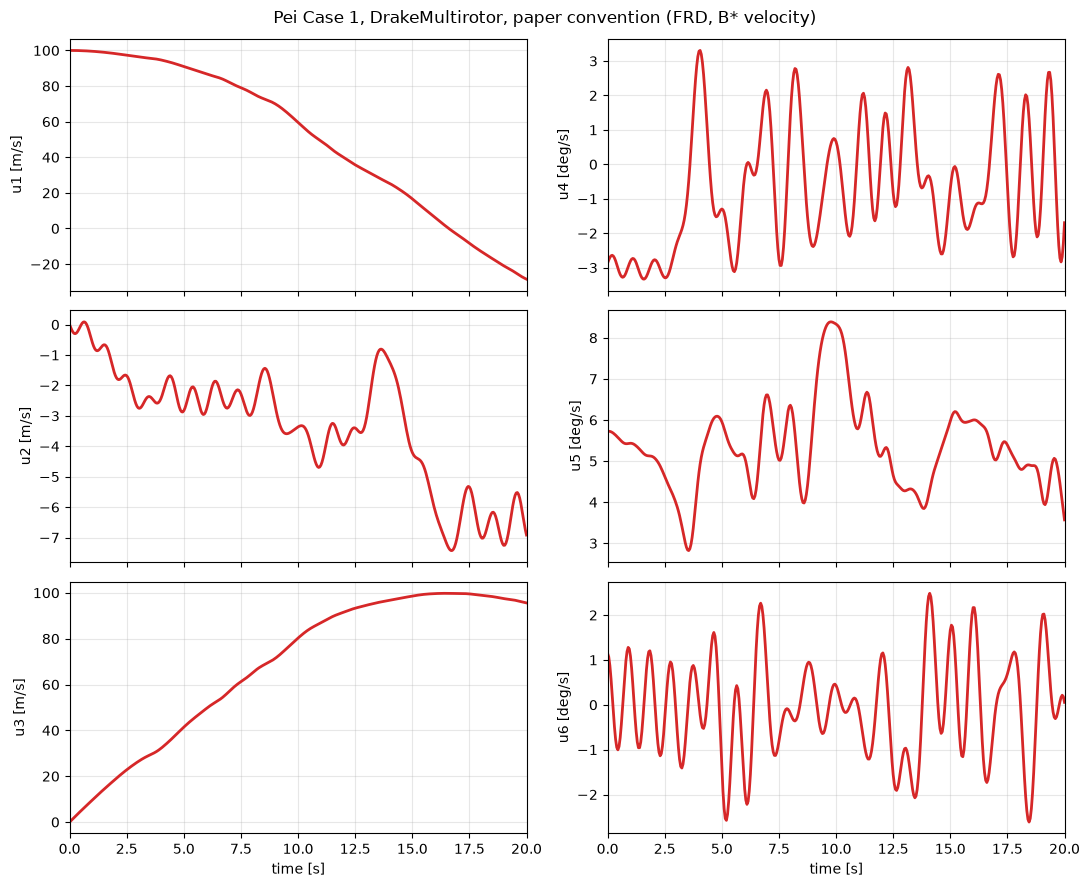

In [5]:
labels = ['u1 [m/s]', 'u2 [m/s]', 'u3 [m/s]', 'u4 [deg/s]', 'u5 [deg/s]', 'u6 [deg/s]']
scale = [1, 1, 1, np.rad2deg(1), np.rad2deg(1), np.rad2deg(1)]
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)
for j, ax in enumerate(axes.T.flat):
    ax.plot(T, scale[j] * U_DRAKE[:, j], color='tab:red', lw=2)
    ax.set_ylabel(labels[j]); ax.grid(True, alpha=0.3); ax.set_xlim(0, T_END)
for ax in axes[-1]:
    ax.set_xlabel('time [s]')
fig.suptitle('Pei Case 1, DrakeMultirotor, paper convention (FRD, B* velocity)')
fig.tight_layout(); plt.show()